# 03. Anime Dataset EDA

    This notebook is for exploratory data analysis only. It does not rewrite the processed dataset and it does not save EDA tables. Plots are saved to `artifacts/plots/eda/`.

In [17]:
from pathlib import Path
from collections import Counter
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
BUILD_DIR = DATA_DIR / "build"
PLOT_DIR = BASE_DIR / "artifacts" / "plots"

ANIME_PATH = PROCESSED_DIR / "anime_dataset.csv"
RATINGS_PATH = PROCESSED_DIR / "ratings_processed.csv"

def split_pipe(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [part.strip() for part in str(value).split("|") if part.strip()]

def count_pipe(value):
    return len(split_pipe(value))

def explode_pipe_counts(series):
    counts = Counter()
    for value in series.dropna():
        counts.update(split_pipe(value))
    return pd.DataFrame(counts.most_common(), columns=["value", "count"])

def parse_duration_minutes(value):
    if pd.isna(value) or str(value).strip() == "":
        return np.nan
    if isinstance(value, (int, float)) and not pd.isna(value):
        return float(value) if float(value) > 0 else np.nan

    text = str(value).strip().lower()
    if re.fullmatch(r"\d+(?:\.\d+)?", text):
        numeric = float(text)
        return numeric if numeric > 0 else np.nan

    hours = re.search(r"(\d+(?:\.\d+)?)\s*(?:hr|hour)", text)
    minutes = re.search(r"(\d+(?:\.\d+)?)\s*min", text)
    seconds = re.search(r"(\d+(?:\.\d+)?)\s*sec", text)
    total = 0.0
    if hours:
        total += float(hours.group(1)) * 60
    if minutes:
        total += float(minutes.group(1))
    if seconds:
        total += float(seconds.group(1)) / 60
    return total if total > 0 else np.nan

def infer_season(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [1, 2, 3]:
        return "winter"
    if month in [4, 5, 6]:
        return "spring"
    if month in [7, 8, 9]:
        return "summer"
    if month in [10, 11, 12]:
        return "fall"
    return np.nan

def add_bar_labels(ax, fmt="{:.0f}"):
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width, patch.get_y() + patch.get_height() / 2, " " + fmt.format(width), va="center", fontsize=9)

def save_current_plot(path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")

EDA_PLOT_DIR = PLOT_DIR / "eda"
EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(ANIME_PATH)
df = df.rename(columns={
    "explicit_genres": "explicit_tags",
    "explicit_genre_weights": "explicit_tag_weights",
})
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
df.head()


Rows: 16,664
Columns: 32


,mal_id,anidb_id,url,image_url,title,title_english,type,source,episodes,status,duration,rating,score,scored_by,rank,popularity,members,favorites,synopsis,aired_year,aired_month,season,genres,explicit_tags,explicit_tag_weights,tags,tag_weights,demographics,studios,relations,recommendations,total_watch_minutes
0,1,23.0,https://myanimelist.net/anime/1/Cowboy_Bebop,https://myanimelist.net/images/anime/4/19644l.jpg,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,24.0,R - 17+ (violence & profanity),8.75,1062212,49.0,41,2057323,89639,"Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on Earth. The...",1998.0,4.0,spring,Action|Award Winning|Sci-Fi,NaN,NaN,Adult Cast|Space|bounty hunter|detective|reverse trap|cyborg|martial arts|cross-dressing|collateral damage|gunfights|swordplay|human enhancement|space trave...,Adult Cast:600|Space:600|bounty hunter:600|detective:400|reverse trap:200|cyborg:100|martial arts:200|cross-dressing:0|collateral damage:0|gunfights:400|swo...,Seinen,Sunrise,Side Story:5|Side Story:17205|Summary:4037,205:319|6:206|889:55|400:47|20057:40|2251:29|4087:19|2025:16|918:14|13601:12|40052:11|467:10|1412:12|42310:9|36563:9|24439:9|30:9|790:6|40256:6|1575:6|474:6...,624.0
1,5,219.0,https://myanimelist.net/anime/5/Cowboy_Bebop__Tengoku_no_Tobira,https://myanimelist.net/images/anime/1439/93480l.jpg,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,115.0,R - 17+ (violence & profanity),8.38,232423,240.0,659,412138,1785,"Another day, another bounty—such is the life of the often unlucky crew of the Bebop. However, this routine is interrupted when Faye, who is chasing a fairly...",2001.0,9.0,summer,Action|Sci-Fi,NaN,NaN,Adult Cast|Space|bounty hunter|gunfights|space travel|plot continuity|music|action|science fiction|comedy|cyberpunk|crime|the arts|nanomachines|neo-noir|mal...,Adult Cast:600|Space:600|bounty hunter:600|gunfights:500|space travel:0|plot continuity:200|music:0|action:500|science fiction:600|comedy:200|cyberpunk:300|...,Seinen,Bones,Parent Story:1,4106:3|21339:2|122:2|9135:1|23279:1|1796:1|393:1|522:1|570:1|1226:1,115.0
2,6,53.0,https://myanimelist.net/anime/6/Trigun,https://myanimelist.net/images/anime/1130/120002l.jpg,Trigun,Trigun,TV,Manga,26.0,Finished Airing,24.0,PG-13 - Teens 13 or older,8.22,401751,424.0,266,834750,17659,"Vash the Stampede is the man with a $$60,000,000,000 bounty on his head. The reason: he's a merciless villain who lays waste to all those that oppose him an...",1998.0,4.0,spring,Action|Adventure|Sci-Fi,NaN,NaN,Adult Cast|cyborg|alien|gunfights|human enhancement|mecha|slapstick|violence|humanoid alien|plot continuity|action|angst|science fiction|Western|adventure|c...,Adult Cast:600|cyborg:200|alien:400|gunfights:600|human enhancement:0|mecha:200|slapstick:400|violence:400|humanoid alien:500|plot continuity:300|action:600...,Shounen,Madhouse,Side Story:4106|Alternative Version:52093,1:94|45:25|25:29|27:83|267:24|411:10|4981:9|24439:7|40256:6|297:6|68:5|400:5|790:4|205:5|1704:3|889:3|1470:3|2001:3|270:3|6030:3|482:2|268:2|777:2|20057:2|1...,624.0
3,7,96.0,https://myanimelist.net/anime/7/Witch_Hunter_Robin,https://myanimelist.net/images/anime/10/19969l.jpg,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,25.0,PG-13 - Teens 13 or older,7.26,46707,3602.0,1993,129825,712,"Though hidden away from the general public, Witches—those with supernatural powers—have always existed in human societies. Neither numerous nor inherently e...",2002.0,7.0,summer,Action|Drama|Mystery|Supernatural,NaN,NaN,Detective|military|painting|undead|immortality|bishounen|extrasensory perception|magic|ghost|cross-dressing|collateral damage|gunfights|bullet time|super po...,Detective:600|military:100|painting:100|detective:400|undead:0|immortality:0|bishounen:100|extrasensory perception:0|magic:300|ghost:200|cross-dressing:100|...,Seinen,Sunrise,NaN,2025:1

## Derived Inspection Fields

    These fields help us inspect quality problems without changing the saved dataset. Season is inferred from month only for analysis, and runtime estimates multiply episode count by parsed duration.

In [18]:
df["season_inferred"] = df["aired_month"].apply(infer_season)
df["season_final"] = df["season"].fillna(df["season_inferred"])
df["duration_minutes"] = df["duration"].apply(parse_duration_minutes)
df["total_watch_minutes"] = df["episodes"] * df["duration_minutes"]
df["tag_count"] = df["tags"].apply(count_pipe)
df["explicit_tag_count"] = df["explicit_tags"].apply(count_pipe)
df["recommendation_edge_count"] = df["recommendations"].apply(count_pipe)
df["relation_edge_count"] = df["relations"].apply(count_pipe)
df[["episodes", "duration", "duration_minutes", "total_watch_minutes", "season", "season_inferred", "season_final"]].head(10)

,episodes,duration,duration_minutes,total_watch_minutes,season,season_inferred,season_final
0,26.0,24.0,24.0,624.0,spring,spring,spring
1,1.0,115.0,115.0,115.0,summer,summer,summer
2,26.0,24.0,24.0,624.0,spring,spring,spring
3,26.0,25.0,25.0,650.0,summer,summer,summer
4,52.0,23.0,23.0,1196.0,fall,summer,fall
5,145.0,23.0,23.0,3335.0,spring,spring,spring
6,24.0,23.0,23.0,552.0,spring,spring,spring
7,52.0,23.0,23.0,1196.0,fall,summer,fall
8,24.0,27.0,27.0,648.0,spring,spring,spring
9,74.0,24.0,24.0,1776.0,spring,spring,spring


## Smart Missingness

    Empty explicit tags are not automatically a problem. They only matter for titles whose rating, genre, or demographics imply explicit content. This avoids marking normal family-safe anime as missing explicit content.

,column,missing,denominator,rule,missing_pct
10,relations,7710,16664,raw empty/null,46.267403
11,recommendations,7404,16664,raw empty/null,44.431109
8,demographics,6474,16664,raw empty/null,38.850216
7,tags,2715,16664,raw empty/null,16.292607
13,explicit_tag_weights,225,2750,only R+/Rx/Hentai/18+,8.181818
12,explicit_tags,225,2750,only R+/Rx/Hentai/18+,8.181818
9,studios,1148,16664,raw empty/null,6.889102
6,genres,588,16664,raw empty/null,3.528565
5,duration,14,16664,raw empty/null,0.084013
3,score,0,16664,raw empty/null,0.000000


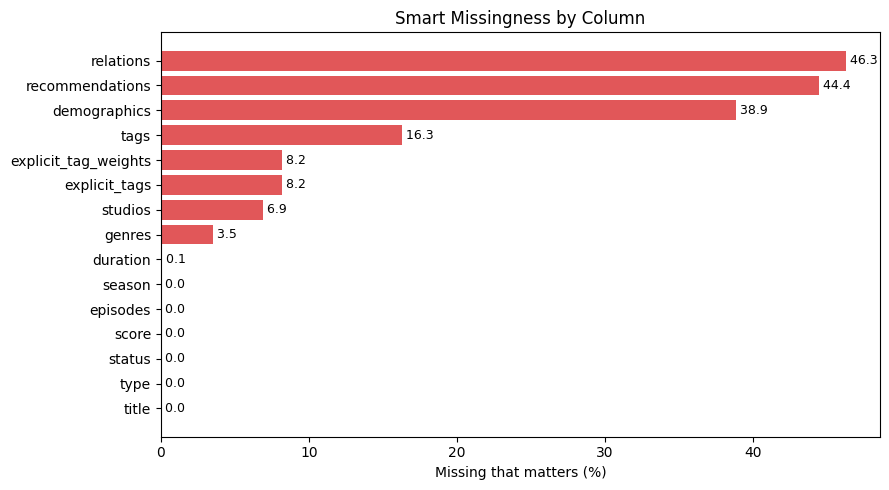

In [19]:
def expects_explicit(row):
    rating = str(row.get("rating", "")).lower()
    genres = set(split_pipe(row.get("genres")))
    demographics = set(split_pipe(row.get("demographics")))
    return rating.startswith("r+") or rating.startswith("rx") or "Hentai" in genres or "18+" in demographics

df["expects_explicit_tags"] = df.apply(expects_explicit, axis=1)

smart_missing = []
for col in ["title", "type", "status", "score", "episodes", "duration", "genres", "tags", "demographics", "studios", "relations", "recommendations"]:
    missing = df[col].isna() | (df[col].astype(str).str.strip() == "")
    smart_missing.append({"column": col, "missing": int(missing.sum()), "denominator": len(df), "rule": "raw empty/null"})

explicit_base = df["expects_explicit_tags"]
for col in ["explicit_tags", "explicit_tag_weights"]:
    missing = df[col].isna() | (df[col].astype(str).str.strip() == "")
    smart_missing.append({"column": col, "missing": int((missing & explicit_base).sum()), "denominator": int(explicit_base.sum()), "rule": "only R+/Rx/Hentai/18+"})

season_missing = df["season_final"].isna() | (df["season_final"].astype(str).str.strip() == "")
smart_missing.append({"column": "season", "missing": int(season_missing.sum()), "denominator": len(df), "rule": "season filled from aired_month if possible"})

missing_df = pd.DataFrame(smart_missing)
missing_df["missing_pct"] = missing_df["missing"] / missing_df["denominator"].replace(0, np.nan) * 100
display(missing_df.sort_values("missing_pct", ascending=False))

plot_df = missing_df.sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["column"], plot_df["missing_pct"], color="#E15759")
ax.set_xlabel("Missing that matters (%)")
ax.set_title("Smart Missingness by Column")
add_bar_labels(ax, "{:.1f}")
save_current_plot(EDA_PLOT_DIR / "smart_missingness_by_column.png")
plt.show()

## Distributions

    Heavy-tailed anime data is hard to read with raw histograms. Bucketed plots and log-scaled popularity plots show the structure without letting a few long-running shows dominate the chart.

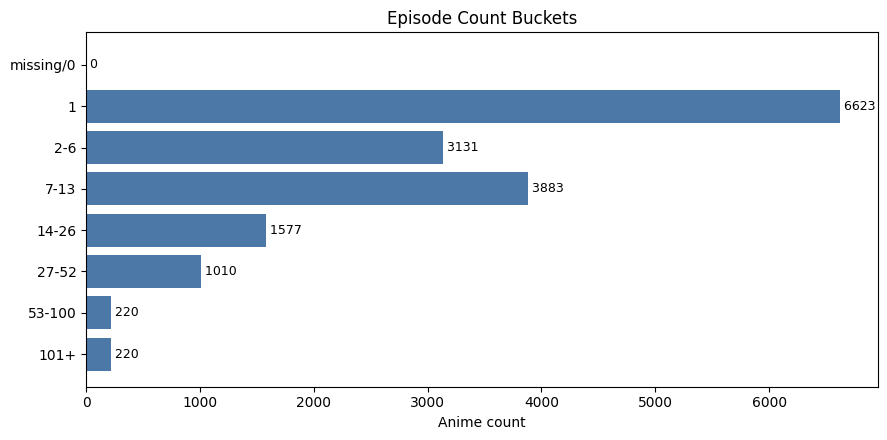

In [20]:
episode_bins = [-1, 0, 1, 6, 13, 26, 52, 100, np.inf]
episode_labels = ["missing/0", "1", "2-6", "7-13", "14-26", "27-52", "53-100", "101+"]
episode_buckets = pd.cut(df["episodes"].fillna(-1), episode_bins, labels=episode_labels, include_lowest=True).value_counts(sort=False).reset_index()
episode_buckets.columns = ["bucket", "count"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(episode_buckets["bucket"][::-1], episode_buckets["count"][::-1], color="#4C78A8")
ax.set_title("Episode Count Buckets")
ax.set_xlabel("Anime count")
add_bar_labels(ax)
save_current_plot(EDA_PLOT_DIR / "episode_count_buckets.png")
plt.show()

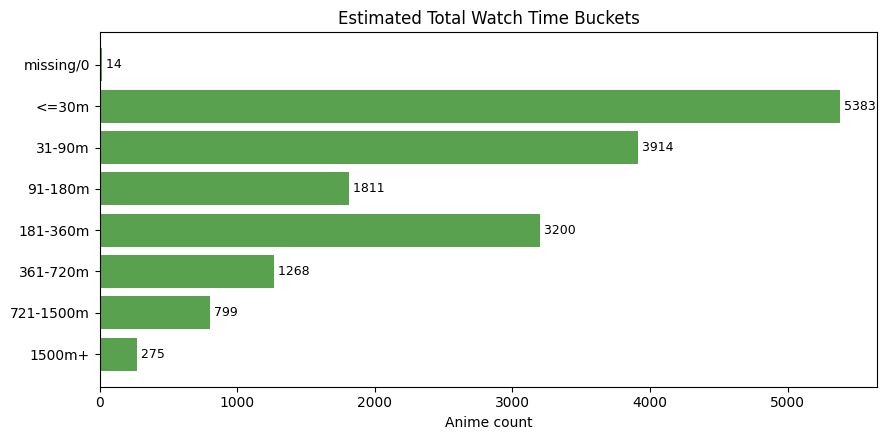

In [21]:
runtime_bins = [-1, 0, 30, 90, 180, 360, 720, 1500, np.inf]
runtime_labels = ["missing/0", "<=30m", "31-90m", "91-180m", "181-360m", "361-720m", "721-1500m", "1500m+"]
runtime_buckets = pd.cut(df["total_watch_minutes"].fillna(-1), runtime_bins, labels=runtime_labels, include_lowest=True).value_counts(sort=False).reset_index()
runtime_buckets.columns = ["bucket", "count"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(runtime_buckets["bucket"][::-1], runtime_buckets["count"][::-1], color="#59A14F")
ax.set_title("Estimated Total Watch Time Buckets")
ax.set_xlabel("Anime count")
add_bar_labels(ax)
save_current_plot(EDA_PLOT_DIR / "total_runtime_buckets.png")
plt.show()

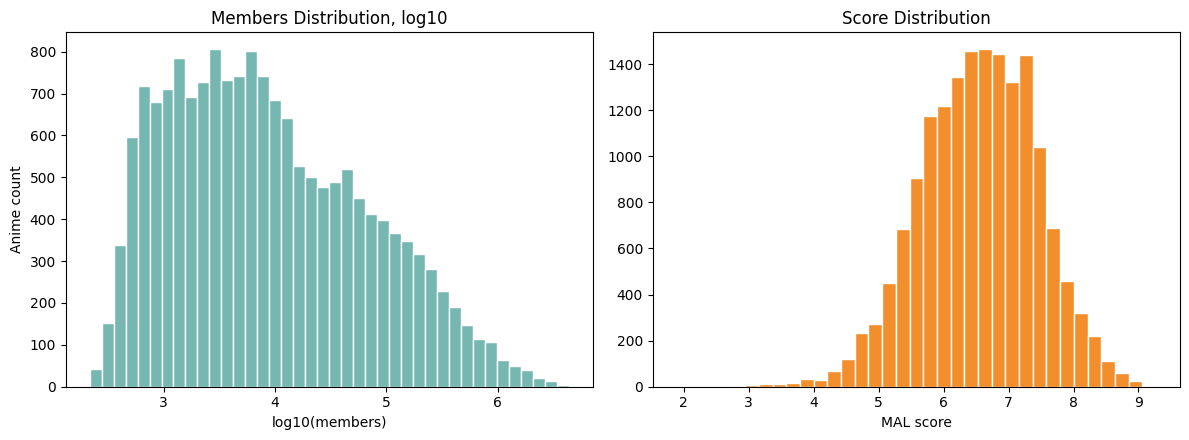

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(np.log10(df["members"].clip(lower=1)), bins=40, color="#76B7B2", edgecolor="white")
axes[0].set_title("Members Distribution, log10")
axes[0].set_xlabel("log10(members)")
axes[0].set_ylabel("Anime count")
axes[1].hist(df["score"].dropna(), bins=35, color="#F28E2B", edgecolor="white")
axes[1].set_title("Score Distribution")
axes[1].set_xlabel("MAL score")
save_current_plot(EDA_PLOT_DIR / "score_members_distributions.png")
plt.show()

## Tags and Explicit Tags

    Full tag counts are displayed in separate cells so the notebook output stays readable. These checks help identify tags that should be moved, renamed, or excluded before feature engineering.

In [23]:
genre_counts = explode_pipe_counts(df["genres"])
genre_counts.head(40)

,value,count
0,Comedy,5787
1,Action,4008
2,Fantasy,3809
3,Adventure,3176
4,Sci-Fi,2744
5,Drama,2382
6,Romance,1983
7,Hentai,1611
8,Supernatural,1262
9,Mystery,915


In [24]:
tag_counts = explode_pipe_counts(df["tags"])
tag_counts.head(80)

,value,count
0,speculative fiction,6303
1,comedy,5504
2,cast,5433
3,action,5171
4,romance,4236
...,...,...
75,Military,656
76,Parody,656
77,school clubs,655
78,cooking,646


In [25]:
explicit_tag_counts = explode_pipe_counts(df["explicit_tags"])
explicit_tag_counts.head(80)

,value,count
0,nudity,2379
1,pornography,1974
2,sex,1863
3,breasts,1479
4,oral,1326
...,...,...
75,maid,174
76,groping,173
77,whipping,169
78,huge breasts,169


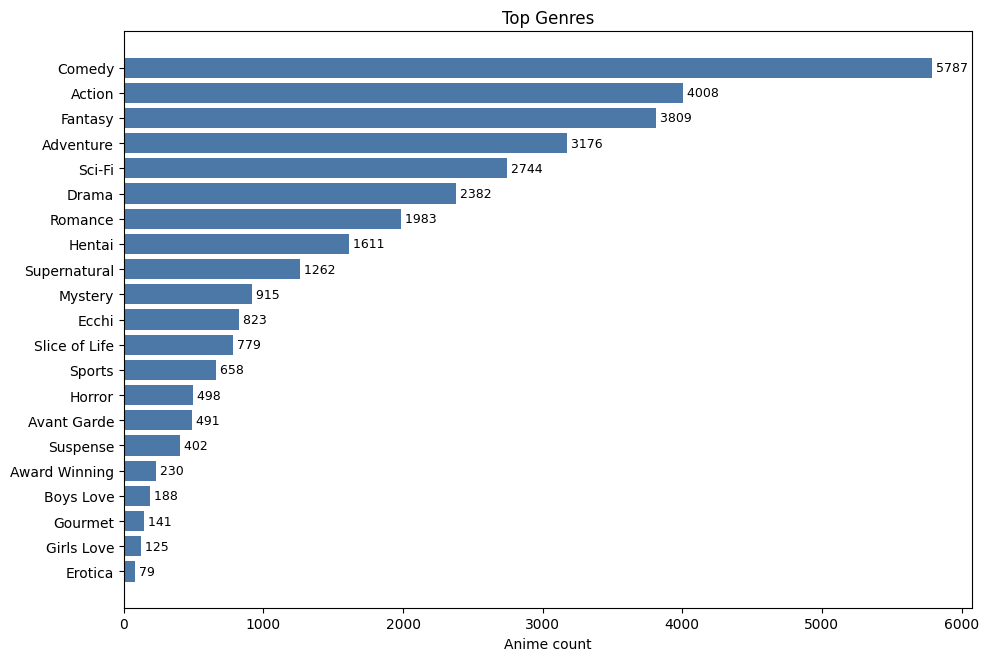

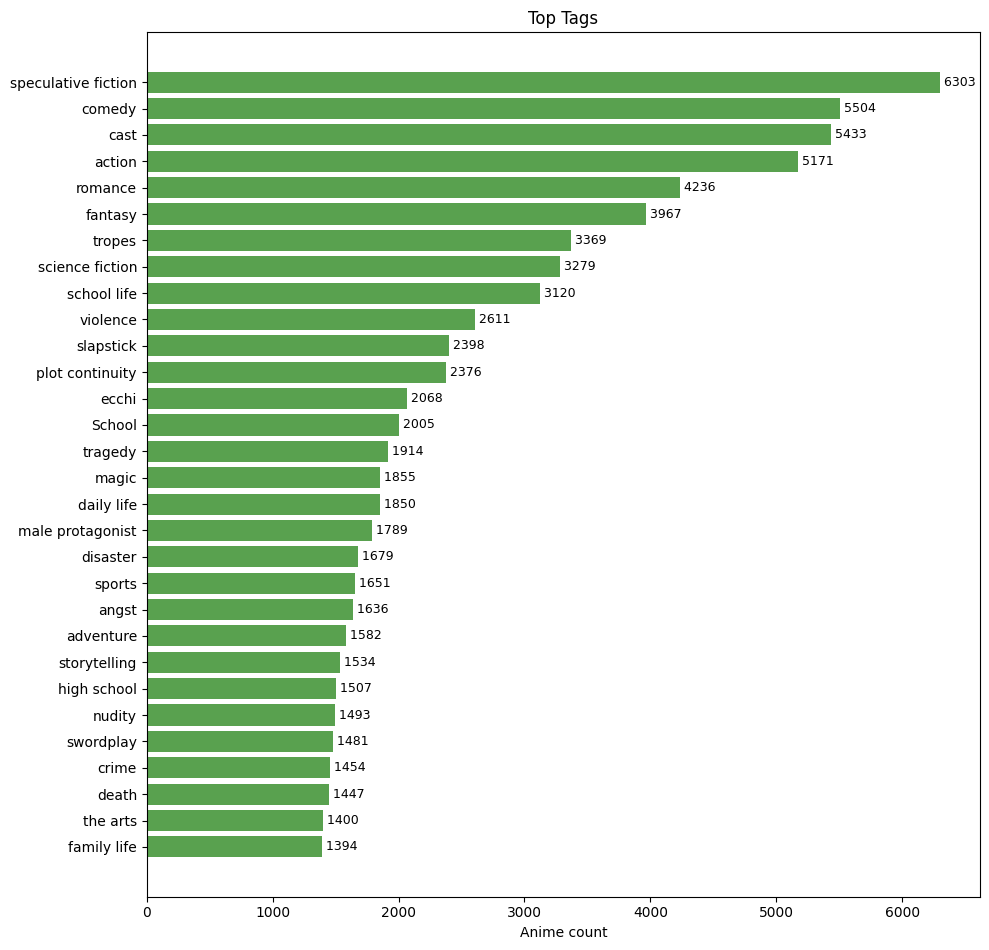

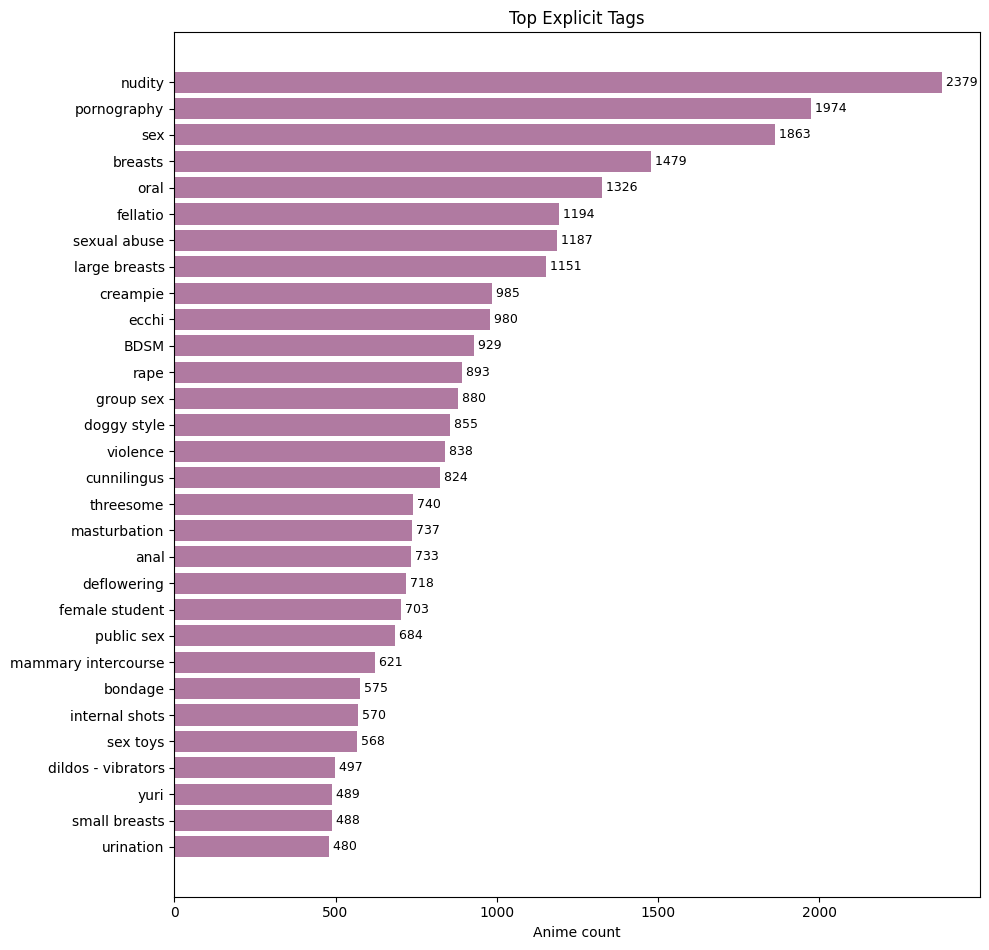

In [26]:
for counts, title, filename, color in [
    (genre_counts.head(25), "Top Genres", "top_genres.png", "#4C78A8"),
    (tag_counts.head(30), "Top Tags", "top_tags.png", "#59A14F"),
    (explicit_tag_counts.head(30), "Top Explicit Tags", "top_explicit_tags.png", "#B07AA1"),
]:
    plot_df = counts.iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.32)))
    ax.barh(plot_df["value"], plot_df["count"], color=color)
    ax.set_title(title)
    ax.set_xlabel("Anime count")
    add_bar_labels(ax)
    save_current_plot(EDA_PLOT_DIR / filename)
    plt.show()

## Interaction and Graph Signals

    Relations and recommendations provide the project with a graph layer. Ratings provide a user-item interaction layer for later recommendation work.

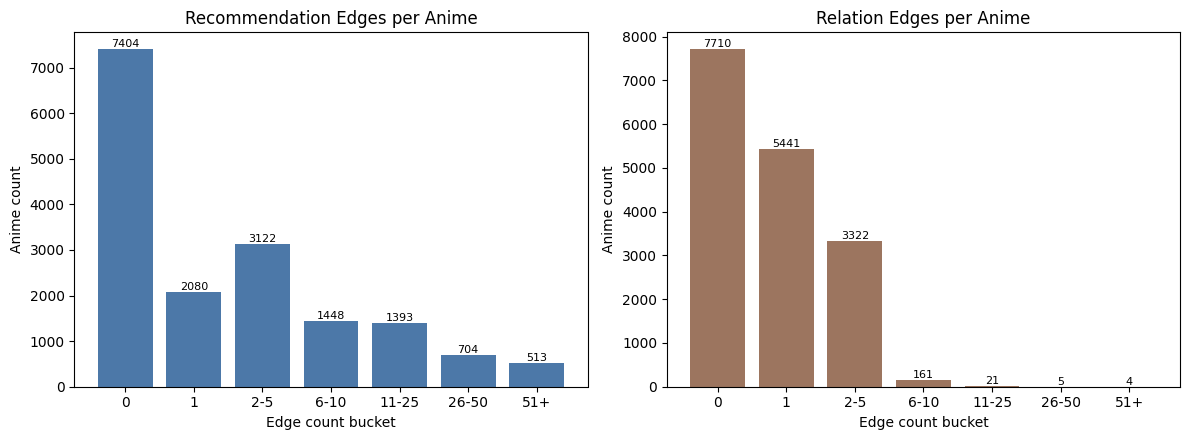

In [27]:
edge_bins = [-1, 0, 1, 5, 10, 25, 50, np.inf]
edge_labels = ["0", "1", "2-5", "6-10", "11-25", "26-50", "51+"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title, color in [
    (axes[0], "recommendation_edge_count", "Recommendation Edges per Anime", "#4C78A8"),
    (axes[1], "relation_edge_count", "Relation Edges per Anime", "#9C755F"),
]:
    buckets = pd.cut(df[col].fillna(-1), edge_bins, labels=edge_labels, include_lowest=True).value_counts(sort=False)
    ax.bar(buckets.index.astype(str), buckets.values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Edge count bucket")
    ax.set_ylabel("Anime count")
    for x, y in enumerate(buckets.values):
        ax.text(x, y, str(int(y)), ha="center", va="bottom", fontsize=8)
save_current_plot(EDA_PLOT_DIR / "edge_count_buckets.png")
plt.show()

## Recommendation and Relation Graph Connections

    For recommendations, global connectivity helps identify commonly co-recommended titles.

    For relations, the useful product question is more specific: a recommendation system should know franchise navigation. It would be strange to recommend season 3 before the viewer has seen the parent entries. At the same time, relation edges are not perfect watch order: prequels can be released later, recap specials may be optional, and franchises such as Gundam can have multiple standalone entry points.

    The relation example below therefore shows the connected relation tree around `Bakemonogatari` (`mal_id=5081`). It is a franchise-connectivity view, not a final watch-order algorithm.


In [28]:
def parse_recommendations(value):
    edges = []
    for part in split_pipe(value):
        if ":" not in part:
            continue
        target, votes = part.rsplit(":", 1)
        try:
            edges.append((int(target), int(float(votes))))
        except ValueError:
            continue
    return edges

def parse_relations(value):
    edges = []
    for part in split_pipe(value):
        if ":" not in part:
            continue
        relation, target = part.rsplit(":", 1)
        try:
            edges.append((relation.strip(), int(target)))
        except ValueError:
            continue
    return edges

id_to_title = dict(zip(df["mal_id"].astype(int), df["title"].fillna("").astype(str)))
id_to_members = dict(zip(df["mal_id"].astype(int), pd.to_numeric(df["members"], errors="coerce").fillna(0)))
valid_ids = set(id_to_title)

recommendation_edges = []
relation_edges = []
for row in df.itertuples(index=False):
    source = int(row.mal_id)
    for target, votes in parse_recommendations(getattr(row, "recommendations", "")):
        if target in valid_ids:
            recommendation_edges.append((source, target, votes))
    for relation, target in parse_relations(getattr(row, "relations", "")):
        if target in valid_ids:
            relation_edges.append((source, target, relation))

print(f"Recommendation edges inside catalog: {len(recommendation_edges):,}")
print(f"Relation edges inside catalog: {len(relation_edges):,}")


Recommendation edges inside catalog: 114,523
Relation edges inside catalog: 14,392


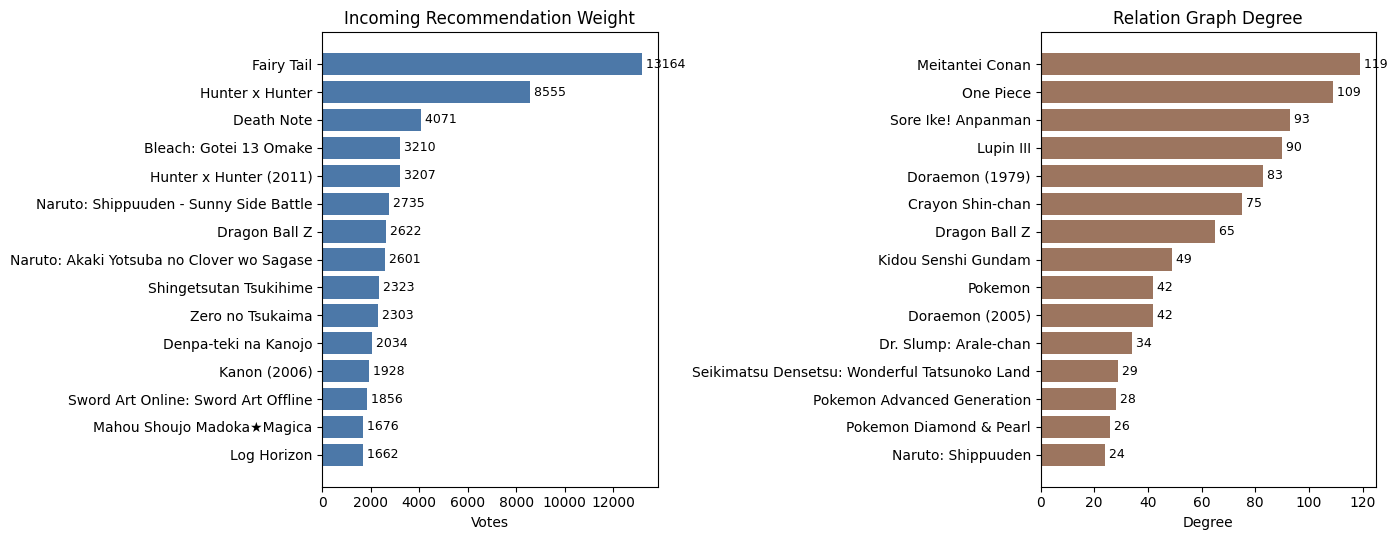

In [29]:
in_votes = Counter()
relation_degree = Counter()
for source, target, votes in recommendation_edges:
    in_votes[target] += votes
for source, target, _relation in relation_edges:
    relation_degree[source] += 1
    relation_degree[target] += 1

top_rec = pd.DataFrame(
    [{"title": id_to_title[k], "weighted_in_votes": v} for k, v in in_votes.items()]
).sort_values("weighted_in_votes", ascending=False).head(15)

top_rel = pd.DataFrame(
    [{"title": id_to_title[k], "relation_degree": v} for k, v in relation_degree.items()]
).sort_values("relation_degree", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(top_rec["title"][::-1], top_rec["weighted_in_votes"][::-1], color="#4C78A8")
axes[0].set_title("Incoming Recommendation Weight")
axes[0].set_xlabel("Votes")
add_bar_labels(axes[0])

axes[1].barh(top_rel["title"][::-1], top_rel["relation_degree"][::-1], color="#9C755F")
axes[1].set_title("Relation Graph Degree")
axes[1].set_xlabel("Degree")
add_bar_labels(axes[1])

save_current_plot(EDA_PLOT_DIR / "graph_central_titles.png")
plt.show()


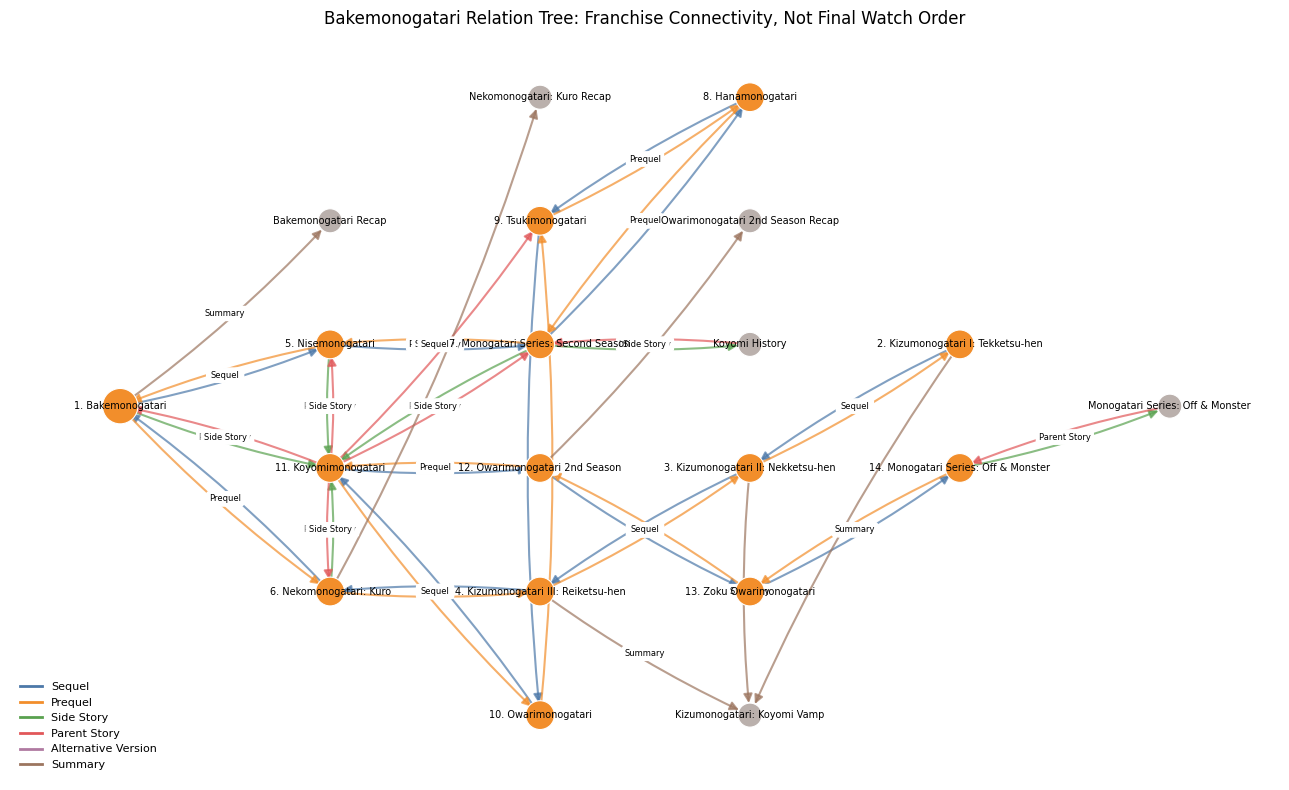

,mal_id,title,distance_from_5081,manual_watch_order_rank_if_used
0,5081,Bakemonogatari,0,1.0
1,6948,Bakemonogatari Recap,1,NaN
2,32268,Koyomimonogatari,1,11.0
3,15689,Nekomonogatari: Kuro,1,6.0
4,11597,Nisemonogatari,1,5.0
5,31758,Kizumonogatari III: Reiketsu-hen,2,4.0
6,17074,Monogatari Series: Second Season,2,7.0
7,38971,Nekomonogatari: Kuro Recap,2,NaN
8,31181,Owarimonogatari,2,10.0
9,35247,Owarimonogatari 2nd Season,2,12.0


In [30]:
navigation_relations = {"Prequel", "Sequel", "Side Story", "Parent Story", "Alternative Version", "Summary"}
relation_colors = {
    "Sequel": "#4C78A8",
    "Prequel": "#F28E2B",
    "Side Story": "#59A14F",
    "Parent Story": "#E15759",
    "Alternative Version": "#B07AA1",
    "Summary": "#9C755F",
}

franchise_root = 5081
relation_graph = nx.Graph()
relation_digraph = nx.DiGraph()
for source, target, relation in relation_edges:
    if relation not in navigation_relations:
        continue
    relation_graph.add_edge(source, target, relation=relation)
    relation_digraph.add_edge(source, target, relation=relation)

if franchise_root in relation_graph:
    component_nodes = nx.node_connected_component(relation_graph, franchise_root)
    franchise_graph = relation_digraph.subgraph(component_nodes).copy()
    levels = nx.single_source_shortest_path_length(relation_graph.subgraph(component_nodes), franchise_root)
    for node, level in levels.items():
        franchise_graph.nodes[node]["level"] = level
    pos = nx.multipartite_layout(franchise_graph, subset_key="level", align="vertical", scale=2.8)

    watch_order_ids = [
        5081, 9260, 31757, 31758, 11597, 15689, 17074, 21855,
        28025, 31181, 32268, 35247, 36999, 57864,
    ]
    watch_order_rank = {anime_id: rank + 1 for rank, anime_id in enumerate(watch_order_ids)}
    node_colors = ["#F28E2B" if node in watch_order_rank else "#BAB0AC" for node in franchise_graph.nodes()]
    node_sizes = [650 if node == franchise_root else 430 if node in watch_order_rank else 300 for node in franchise_graph.nodes()]

    fig, ax = plt.subplots(figsize=(13, 8))
    for relation, color in relation_colors.items():
        edges = [(u, v) for u, v, d in franchise_graph.edges(data=True) if d.get("relation") == relation]
        nx.draw_networkx_edges(
            franchise_graph, pos, edgelist=edges, ax=ax, alpha=0.7,
            width=1.5, edge_color=color, arrows=True, arrowsize=13,
            connectionstyle="arc3,rad=0.05", label=relation,
        )
    nx.draw_networkx_nodes(franchise_graph, pos, node_color=node_colors, node_size=node_sizes, edgecolors="white", linewidths=0.8, ax=ax)
    labels = {
        node: (f"{watch_order_rank[node]}. " if node in watch_order_rank else "") + id_to_title.get(node, str(node))[:32]
        for node in franchise_graph.nodes()
    }
    nx.draw_networkx_labels(franchise_graph, pos, labels=labels, font_size=7, ax=ax)
    edge_labels = {(u, v): d.get("relation", "") for u, v, d in franchise_graph.edges(data=True)}
    nx.draw_networkx_edge_labels(franchise_graph, pos, edge_labels=edge_labels, font_size=6, rotate=False, ax=ax)
    ax.set_title("Bakemonogatari Relation Tree: Franchise Connectivity, Not Final Watch Order")
    legend_handles = [Line2D([0], [0], color=color, lw=2, label=relation) for relation, color in relation_colors.items()]
    ax.legend(handles=legend_handles, loc="lower left", fontsize=8, frameon=False)
    ax.axis("off")
    save_current_plot(EDA_PLOT_DIR / "bakemonogatari_relation_tree.png")
    plt.show()

    relation_tree_table = pd.DataFrame([
        {
            "mal_id": node,
            "title": id_to_title.get(node, ""),
            "distance_from_5081": levels[node],
            "manual_watch_order_rank_if_used": watch_order_rank.get(node, np.nan),
        }
        for node in sorted(component_nodes, key=lambda item: (levels[item], id_to_title.get(item, "")))
    ])
    display(relation_tree_table)
else:
    print("Bakemonogatari was not found in the relation graph.")


Ratings preview:


,userID,animeID,rating
0,1,431,10
1,1,1535,10
2,1,15315,7
3,1,14345,10
4,1,11757,10


Ratings rows: 148,170,496
Unique users: 1,774,522
Unique anime: 20,237


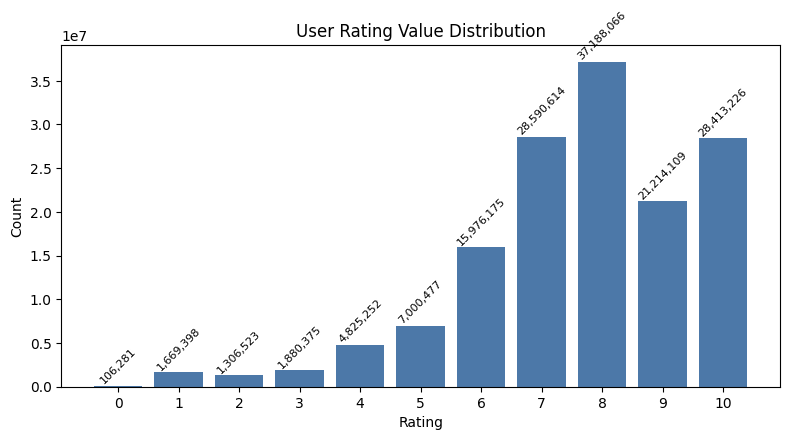

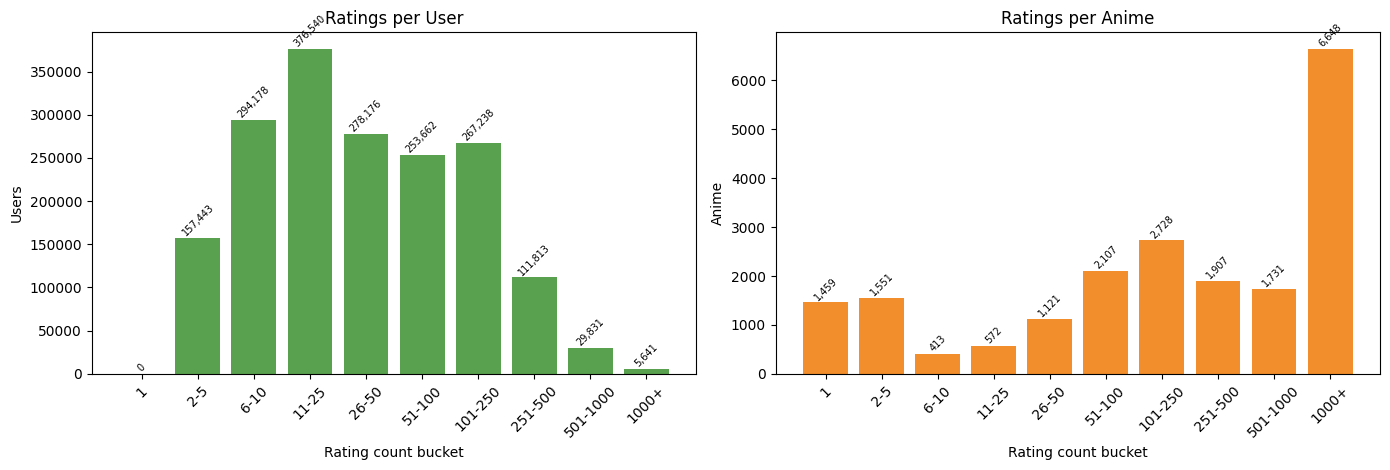

In [31]:
if RATINGS_PATH.exists():
    preview = pd.read_csv(RATINGS_PATH, nrows=5)
    print("Ratings preview:")
    display(preview)

    rating_rows = 0
    user_rating_counts = Counter()
    anime_rating_counts = Counter()
    rating_value_counts = Counter()
    for chunk in pd.read_csv(RATINGS_PATH, chunksize=1_000_000):
        rating_rows += len(chunk)
        if "userID" in chunk:
            user_rating_counts.update(chunk["userID"].dropna().astype(int).tolist())
        if "animeID" in chunk:
            anime_rating_counts.update(chunk["animeID"].dropna().astype(int).tolist())
        if "rating" in chunk:
            rating_value_counts.update(chunk["rating"].dropna().astype(int).tolist())

    print(f"Ratings rows: {rating_rows:,}")
    print(f"Unique users: {len(user_rating_counts):,}")
    print(f"Unique anime: {len(anime_rating_counts):,}")

    rating_distribution = pd.DataFrame(sorted(rating_value_counts.items()), columns=["rating", "count"])
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(rating_distribution["rating"].astype(str), rating_distribution["count"], color="#4C78A8")
    ax.set_title("User Rating Value Distribution")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
    for x, y in enumerate(rating_distribution["count"]):
        ax.text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=8, rotation=45)
    save_current_plot(EDA_PLOT_DIR / "rating_counts.png")
    plt.show()

    quantity_bins = [0, 1, 5, 10, 25, 50, 100, 250, 500, 1000, np.inf]
    quantity_labels = ["1", "2-5", "6-10", "11-25", "26-50", "51-100", "101-250", "251-500", "501-1000", "1000+"]
    user_quantity = pd.cut(pd.Series(user_rating_counts.values()), quantity_bins, labels=quantity_labels, include_lowest=True).value_counts(sort=False)
    anime_quantity = pd.cut(pd.Series(anime_rating_counts.values()), quantity_bins, labels=quantity_labels, include_lowest=True).value_counts(sort=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].bar(user_quantity.index.astype(str), user_quantity.values, color="#59A14F")
    axes[0].set_title("Ratings per User")
    axes[0].set_xlabel("Rating count bucket")
    axes[0].set_ylabel("Users")
    axes[0].tick_params(axis="x", rotation=45)
    for x, y in enumerate(user_quantity.values):
        axes[0].text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=7, rotation=45)

    axes[1].bar(anime_quantity.index.astype(str), anime_quantity.values, color="#F28E2B")
    axes[1].set_title("Ratings per Anime")
    axes[1].set_xlabel("Rating count bucket")
    axes[1].set_ylabel("Anime")
    axes[1].tick_params(axis="x", rotation=45)
    for x, y in enumerate(anime_quantity.values):
        axes[1].text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=7, rotation=45)

    save_current_plot(EDA_PLOT_DIR / "rating_quantity_distribution.png")
    plt.show()
else:
    print("ratings_processed.csv is not available yet.")
